# ***Customer Segmentation Analysis using K-Means Clustering***

## *Problem Statement*

*The objective of this project is to segment customers of an e-commerce company based on their purchasing behavior. By identifying distinct customer groups, businesses can apply targeted marketing strategies to improve customer satisfaction and increase revenue.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df= pd.read_csv("ifood_df.csv")
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


## *Data Understanding*

The dataset contains customer information such as income, spending behavior, and purchase activity.

Key features used in this analysis:

- Income: Annual income of the customer
- MntTotal: Total amount spent by the customer
- Recency: Number of days since last purchase
- NumWebPurchases: Number of online purchases made by the customer*

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [5]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [6]:
df.isnull().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

## *Descriptive Statistics*

To understand overall customer behavior, we calculate the average values of key variables:

- Average Income ≈ 51,622
- Average Spending ≈ 562
- Average Recency ≈ 49 days

This indicates moderate spending behavior and engagement among customers.

In [7]:
df[['Income', 'MntTotal', 'Recency']].mean()

Income      51622.094785
MntTotal      562.764626
Recency        49.009070
dtype: float64

## *Methodology*

The following steps were performed:

1. Data Exploration and Cleaning
2. Feature Selection
3. Feature Scaling
4. Elbow Method to determine optimal clusters
5. K-Means Clustering for segmentation

In [8]:
##Feature Selection:

X= df[['Income', 'MntTotal', 'Recency', 'NumWebPurchases']]
X.head()

,Income,MntTotal,Recency,NumWebPurchases
0,58138.0,1529,58,8
1,46344.0,21,38,1
2,71613.0,734,26,8
3,26646.0,48,26,2
4,58293.0,407,94,5


In [9]:
##Scaling:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

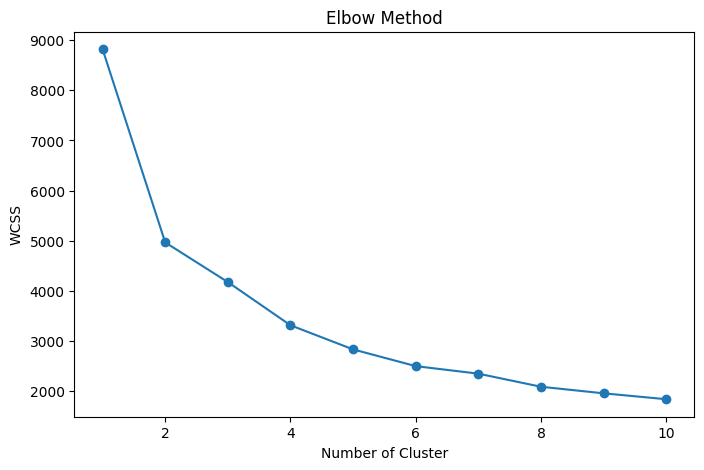

In [10]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Cluster')
plt.ylabel('WCSS')
plt.show()

In [11]:
## Clustering:

kmeans= KMeans(n_clusters=4, random_state=42)
df['Cluster']= kmeans.fit_predict(X_scaled)

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,1,0,0,1529,1441,0,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,1,0,0,21,15,0,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,0,0,1,0,0,734,692,0,2
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,0,0,1,0,0,48,43,0,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,1,407,392,0,3


### *Clustering Results*

Using the Elbow Method, the optimal number of clusters was determined to be 4. The K-Means algorithm was applied to segment customers into four distinct groups.

In [12]:
## Cluster Summary:

df.groupby('Cluster')[['Income', 'MntTotal', 'Recency']].mean()

,Income,MntTotal,Recency
Cluster,,,
0,76279.187617,1358.804878,55.823640
1,34430.709184,100.224490,25.267007
2,60359.747592,727.325626,39.011561
3,38226.453097,142.015929,76.472566


### *Cluster-wise Summary*
This table shows average values of income, spending, and recency for each cluster.

## *Visualization*

The following visualizations were used to understand customer segments:

- Income vs Spending:
  Shows how customers differ in terms of purchasing power and spending behavior.

- Spending vs Recency:
  Shows customer activity levels (active vs inactive customers).

- Cluster Distribution:
  Displays the number of customers in each segment.

These visualizations help in understanding both customer value and engagement patterns.

#### *Income vs Spending*

This plot shows the relationship between customer income and total spending. It helps identify high-value customers who have both high income and high spending.

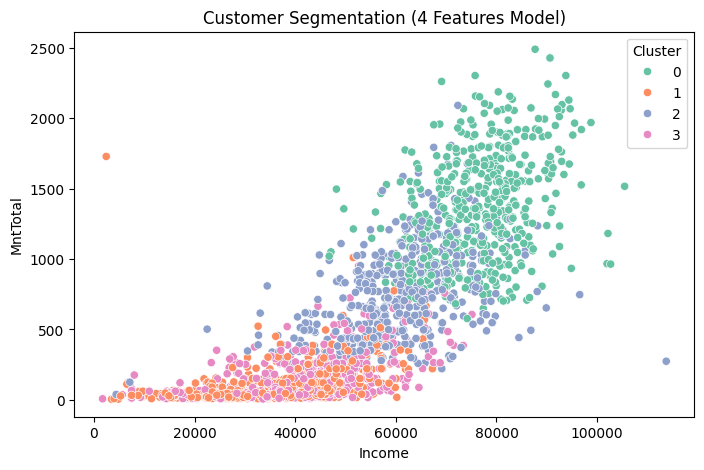

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Income'],
    y=df['MntTotal'],
    hue=df['Cluster'],
    palette='Set2'
)
plt.title('Customer Segmentation (4 Features Model)')
plt.show()

#### *Spending vs Recency*

This plot shows customer spending behavior against recency. Customers with low recency are more active, while high recency indicates inactive customers.

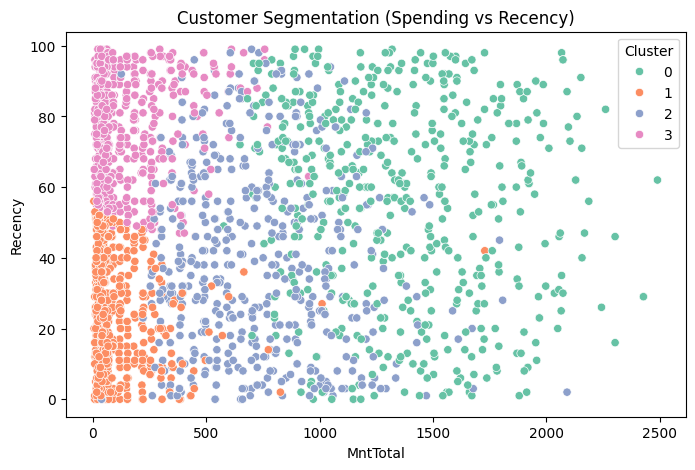

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['MntTotal'],
    y=df['Recency'],
    hue=df['Cluster'],
    palette='Set2'
)
plt.title('Customer Segmentation (Spending vs Recency)')
plt.show()

#### *Cluster Distribution*

This plot shows the number of customers in each cluster. It helps understand how customers are distributed across segments.

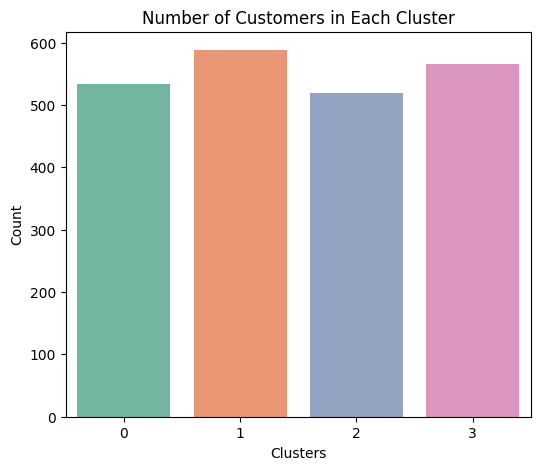

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=df, hue='Cluster', palette='Set2', legend=False)
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Clusters')
plt.ylabel('Count')
plt.show()

### *Cluster-wise Feature Distribution*

These boxplots compare income, spending, and recency across different customer segments.

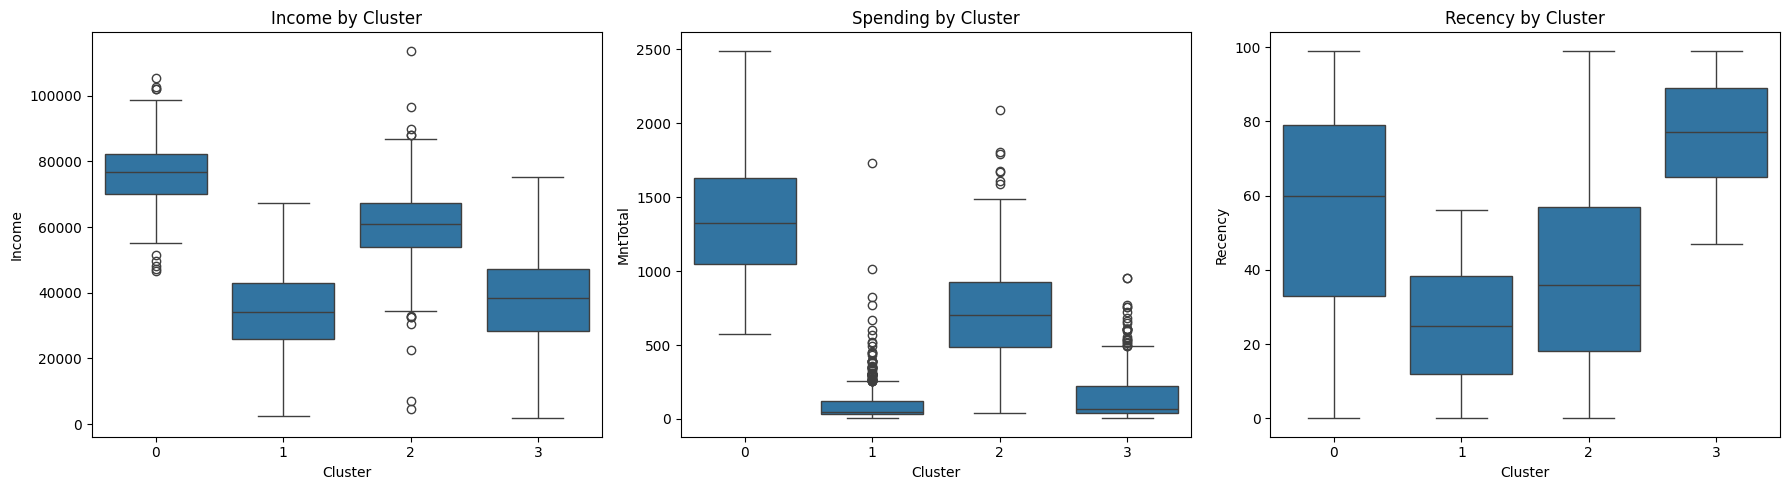

In [16]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.boxplot(x='Cluster', y='Income', data=df)
plt.title('Income by Cluster')

plt.subplot(1,3,2)
sns.boxplot(x='Cluster', y='MntTotal', data=df)
plt.title('Spending by Cluster')

plt.subplot(1,3,3)
sns.boxplot(x='Cluster',y='Recency', data=df)
plt.title('Recency by Cluster')

plt.tight_layout()
plt.show()

## *Insights and Recommendations*

- Customers were segmented into four distinct groups based on income, spending, recency and online purchase behavior.

- High-value active customers (high income, high spending, low recency) are the most valuable segment and should be targeted with loyalty programs, exclusive offers and premium services.

- High-value inactive customers (high income, high spending, high recency) represent a strong opportunity for re-engagement through personalized marketing campaigns and special offers.

- Low-value active customers (low spending but active customers) can be encouraged to increase their spending through discounts, product recommendations and promotions.

- Low-value inactive customers (low spending and high recency) require re-engagement strategies such as targeted advertisements, reminders and incentives.

- Overall, customer segmentation enables businesses to design targeted marketing strategies, improve customer retention and enhance revenue generation.

## *Conclusion*

This project successfully applied K-Means clustering to segment customers into meaningful groups based on their behavior and spending patterns. The analysis provides actionable insights that can help businesses improve customer engagement, optimize marketing strategies, and increase overall profitability.